In [ ]:
# ============================================================================
# COLAB GPU T4 SETUP - Run this cell first!
# ============================================================================
import os
import sys
from pathlib import Path

# Detect Colab environment
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules
if not IN_COLAB:
    try:
        from google.colab import drive
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

print(f"{'🔵 COLAB' if IN_COLAB else '🔷 LOCAL'} Environment detected")

# Mount Google Drive if in Colab
if IN_COLAB:
    try:
        from google.colab import drive
        print("Mounting Google Drive...")
        drive.mount("/content/drive", force_remount=False)
        print("✓ Google Drive mounted at /content/drive/MyDrive")
    except Exception as e:
        print(f"⚠ Drive mount error: {e}")

# GPU check for T4
try:
    import torch
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
        print(f"✓ GPU Available: {gpu_name} ({gpu_memory:.1f} GB)")
        print(f"  T4 GPU has 16GB VRAM. Monitor memory usage in GPU-heavy cells.")
    else:
        print("⚠ GPU NOT detected. CPU-only mode (slower processing).")
except ImportError:
    print("⚠ PyTorch not yet installed")

# Safe path resolution for both local and Colab
def get_project_root() -> Path:
    """Resolve project root for both local and Colab environments."""
    def _looks_like_root(p: Path) -> bool:
        return (p / 'README.md').exists() and (p / 'code').exists() and (p / 'data').exists()

    candidates = []
    cwd = Path.cwd().resolve()
    
    # Check environment variable first
    env_root = os.environ.get('PROJECT_ROOT', '').strip()
    if env_root:
        candidates.append(Path(env_root))
    
    # Add cwd and parents
    candidates.extend([cwd] + list(cwd.parents))
    
    # Add Colab paths
    if IN_COLAB:
        candidates.extend([
            Path('/content/drive/MyDrive/Project'),
            Path('/content/drive/My Drive/Project'),
        ])
    else:
        # Local paths
        candidates.extend([
            Path('/mnt/g/My Drive/Project'),
            Path('G:/My Drive/Project'),
        ])
    
    # Deduplicate and find first valid
    seen = set()
    for p in candidates:
        s = str(p)
        if s not in seen:
            seen.add(s)
            if _looks_like_root(p):
                return p
    
    # Fallback
    if _looks_like_root(cwd):
        return cwd
    
    raise FileNotFoundError(
        f"Project root not found.\nCurrent: {cwd}\n"
        f"Checked (first 5):\n" + "\n".join(f"  {p}" for p in candidates[:5])
    )

PROJECT_ROOT = get_project_root()
print(f"✓ Project root: {PROJECT_ROOT}")
print("=" * 70)

### Stage 7: Input-Output (IO) Extension

- Input: The predicted risk scores from the main text-classification task
- This step maps targeted products to exporter-side IO sectors and tests whether the highest-risk notifications are disproportionately concentrated in more central and downstream-dependent sectors. 
- The goal is to move from prediction to economic relevance by assessing whether predicted trade barriers fall on sectors with greater potential for domestic spillovers.

**7.1. Setup**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


def _looks_like_root(p: Path) -> bool:
    return (p / 'README.md').exists() and (p / 'code').exists() and (p / 'data').exists()


def _candidate_paths():
    cwd = Path.cwd().resolve()
    seen = set()

    def _push(path: Path):
        p = path.resolve()
        s = str(p)
        if s not in seen:
            seen.add(s)
            return p
        return None

    for p in [cwd, *cwd.parents]:
        q = _push(p)
        if q is not None:
            yield q

    for p in [
        Path('/content/drive/MyDrive/Project'),
        Path('/content/drive/My Drive/Project'),
        Path('/mnt/g/My Drive/Project'),
        Path(r'G:/My Drive/Project'),
    ]:
        q = _push(p)
        if q is not None:
            yield q


BASE = next((p for p in _candidate_paths() if _looks_like_root(p)), Path.cwd().resolve())

PRED_PATH = BASE / 'data/cleaned_data/test_predictions_all_models.csv'  # has country/hs4 product level
HS_ISIC_PATH = BASE / 'data/cleaned_data/train_notif_hs4_country_isic4_2digit_long.csv'
IO_PATH = BASE / 'data/raw/io_country_isic2_preavg.csv'

OUT_IO_MERGED = BASE / 'data/cleaned_data/test_with_io_merged.csv'
OUT_SUMMARY_A = BASE / 'data/cleaned_data/io_risk_diff_in_means.csv'
OUT_BINS = BASE / 'data/cleaned_data/io_binned_scatter_data.csv'

FIG_DIR = BASE / 'fig'
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_A_CENTRALITY = FIG_DIR / 'fig_io_A_centrality_shift_key_exporters.png'
FIG_A_DOWNSTREAM = FIG_DIR / 'fig_io_A_downstream_shift_key_exporters.png'
FIG_B_WITHIN = FIG_DIR / 'fig_io_B_binned_within_exporter.png'
FIG_B_POOLED_FE = FIG_DIR / 'fig_io_B_binned_pooled_fe.png'

print('BASE =', BASE)
print('DistilBERT OOS source =', PRED_PATH)

BASE = /content/drive/MyDrive/Project
DistilBERT OOS source = /content/drive/MyDrive/Project/data/cleaned_data/test_predictions_all_models.csv


**7.2. Build final-test IO-augmented dataset (2024-2025)**

Restrict to 2024-25 final test, harmonize exporter/HS/ISIC codes, construct from HS4 product to ISIC shares, merge IO exposures and aggregate back to (notification, exporter, product) with weighted means.

In [8]:
# Out-of-sample predictions (with country/hs4 keys)
pred = pd.read_csv(PRED_PATH, dtype={'hs4': str})
# Rename the main prediction column to p_hat for downstream use
if 'p_text_country' in pred.columns:
    pred['p_hat'] = pred['p_text_country']
elif 'p_text' in pred.columns:
    pred['p_hat'] = pred['p_text']
else:
    raise ValueError('Expected p_text_country or p_text column in predictions file')

# Enforce final test window
pred['distribution_date'] = pd.to_datetime(pred['distribution_date'], errors='coerce', utc=True)
pred = pred.dropna(subset=['distribution_date']).copy()
pred = pred[(pred['distribution_date'] >= '2024-01-01') & (pred['distribution_date'] <= '2025-12-31')].copy()

# Exporter name -> ISO3 (align with IO table country codes)
country_map = {
    'Indonesia': 'IDN', 'Malaysia': 'MYS', 'Thailand': 'THA', 'Cambodia': 'KHM',
    'Myanmar (Burma)': 'MMR', 'Philippines': 'PHL', 'Vietnam': 'VNM', 'Laos': 'LAO',
    'Singapore': 'SGP', 'Brunei': 'BRN',
}
pred['country_iso'] = pred['country'].map(country_map)

# HS4-ISIC mapping with shares
hs_long = pd.read_csv(HS_ISIC_PATH, dtype={'isic4': str, 'hs4': str})
hs_long = hs_long.rename(columns={'isic4': 'isic2'})

# IO exposure by country-ISIC2
io = pd.read_csv(IO_PATH, dtype={'isic2': str})

# Standardize keys
pred['hs4'] = pred['hs4'].astype(str).str.zfill(4)
hs_long['hs4'] = hs_long['hs4'].astype(str).str.zfill(4)
hs_long['isic2'] = hs_long['isic2'].astype(str).str.zfill(2)
io['isic2'] = io['isic2'].astype(str).str.zfill(2)

# key columns
key_cols = ['notified_document', 'country', 'hs4']

# Keep unique hs4-isic shares per key (renormalized)
hs_map = (
    hs_long[key_cols + ['isic2', 'share']]
    .dropna(subset=['isic2', 'share'])
    .groupby(key_cols + ['isic2'], as_index=False)['share']
    .sum()
)
hs_map['share'] = hs_map['share'] / hs_map.groupby(key_cols)['share'].transform('sum')

# merge pred to sector shares
pred_long = pred.merge(hs_map, on=key_cols, how='left', validate='m:m')

# merge IO exposures by ISO country + ISIC2
io_keep = io[['country', 'isic2', 'centrality', 'dd_logU']].copy().rename(columns={'country': 'country_iso'})
pred_long = pred_long.merge(io_keep, on=['country_iso', 'isic2'], how='left')

# Weighted means that preserve missingness (no false zeros)
def weighted_mean_ignore_nan(v: pd.Series, w: pd.Series):
    m = v.notna() & w.notna()
    if m.sum() == 0:
        return np.nan
    ww = w[m]
    if ww.sum() == 0:
        return np.nan
    return float((v[m] * ww).sum() / ww.sum())

# Weighted aggregation back to (notif,country,hs4)
base_cols = ['notified_document', 'country', 'hs4', 'distribution_date', 'ym', 'Y_struct_abn', 'p_hat']
base_cols = [c for c in base_cols if c in pred_long.columns]

pred_io = (
    pred_long.groupby(base_cols, as_index=False)
             .apply(lambda g: pd.Series({
                 'centrality': weighted_mean_ignore_nan(g['centrality'], g['share']),
                 'dd_logU': weighted_mean_ignore_nan(g['dd_logU'], g['share']),
                 'io_share_covered': float(g.loc[g['centrality'].notna(), 'share'].sum()) if 'share' in g.columns else np.nan
             }), include_groups=False)
             .reset_index(drop=True)
)

pred_io.to_csv(OUT_IO_MERGED, index=False, encoding='utf-8')
print('Saved final-test IO merged file:', OUT_IO_MERGED)

print('Shape:', pred_io.shape)
print('Mean io_share_covered:', pred_io['io_share_covered'].mean())

print('Date range:', pred_io['distribution_date'].min(), '->', pred_io['distribution_date'].max())
print('Missingness:')
print(pred_io[['centrality', 'dd_logU']].isna().mean())

Saved final-test IO merged file: /content/drive/MyDrive/Project/data/cleaned_data/test_with_io_merged.csv
Shape: (10404, 9)
Mean io_share_covered: 0.7972895040369089
Date range: 2024-01-04 00:00:00+00:00 -> 2025-11-24 00:00:00+00:00
Missingness:
centrality    0.20271
dd_logU       0.20271
dtype: float64


**7.3. Define risk groups and key exporters**

Define the within-exporter top-decile risk group and identify key exporters for poster figures.


In [9]:
# Top-decile risk within exporter
pred_io['risk_q90_within_exporter'] = pred_io.groupby('country')['p_hat'].transform(lambda s: s.quantile(0.9))
pred_io['high_risk_top10_within_exporter'] = (pred_io['p_hat'] >= pred_io['risk_q90_within_exporter']).astype(int)

# Also keep pooled top-decile for reference
q90_global = pred_io['p_hat'].quantile(0.9)
pred_io['high_risk_top10_global'] = (pred_io['p_hat'] >= q90_global).astype(int)

# choose 2 key exporters (largest sample in final test set)
key_exporters = pred_io['country'].value_counts().head(2).index.tolist()
print('Key exporters for poster facets:', key_exporters)

# quick diagnostics
print('\nRisk diagnostics (within-exporter top decile):')
print(pred_io.groupby('country')['high_risk_top10_within_exporter'].mean().sort_values(ascending=False))

print('\nMissingness in IO variables:')
print(pred_io[['centrality', 'dd_logU']].isna().mean())

Key exporters for poster facets: ['Vietnam', 'Thailand']

Risk diagnostics (within-exporter top decile):
country
Myanmar (Burma)    0.109339
Indonesia          0.103340
Malaysia           0.102507
Thailand           0.102317
Philippines        0.101601
Cambodia           0.101023
Vietnam            0.100852
Laos               0.100000
Name: high_risk_top10_within_exporter, dtype: float64

Missingness in IO variables:
centrality    0.20271
dd_logU       0.20271
dtype: float64


**7.4. Descriptive comparison: high-risk vs the rest**
- compute difference-in-means for `centrality` and `dd_logU` (downstream dependence)
- compute difference-in-means within exporter
- add pooled exporter-FE version as robustness

In [10]:
# ------------------------------
# A) Difference-in-means / distribution shift
# ------------------------------

io_vars = ['centrality', 'dd_logU']
rows = []

# within-exporter differences (high-risk - rest)
for exporter, g in pred_io.groupby('country'):
    for var in io_vars:
        gg = g[[var, 'high_risk_top10_within_exporter']].dropna()
        if gg.empty or gg['high_risk_top10_within_exporter'].nunique() < 2:
            continue
        mean_high = gg.loc[gg['high_risk_top10_within_exporter'] == 1, var].mean()
        mean_rest = gg.loc[gg['high_risk_top10_within_exporter'] == 0, var].mean()
        rows.append({
            'scope': 'within_exporter',
            'country': exporter,
            'variable': var,
            'mean_high_risk': mean_high,
            'mean_rest': mean_rest,
            'diff_high_minus_rest': mean_high - mean_rest,
            'n': len(gg)
        })

# pooled with exporter fixed effects (demeaned within exporter)
for var in io_vars:
    tmp = pred_io[[var, 'country', 'high_risk_top10_within_exporter']].dropna().copy()
    tmp['var_fe'] = tmp[var] - tmp.groupby('country')[var].transform('mean')
    tmp['risk_fe'] = tmp['high_risk_top10_within_exporter'] - tmp.groupby('country')['high_risk_top10_within_exporter'].transform('mean')

    rows.append({
        'scope': 'pooled_exporter_fe',
        'country': 'ALL',
        'variable': var,
        'mean_high_risk': tmp.loc[tmp['high_risk_top10_within_exporter'] == 1, 'var_fe'].mean(),
        'mean_rest': tmp.loc[tmp['high_risk_top10_within_exporter'] == 0, 'var_fe'].mean(),
        'diff_high_minus_rest': tmp.loc[tmp['high_risk_top10_within_exporter'] == 1, 'var_fe'].mean() - tmp.loc[tmp['high_risk_top10_within_exporter'] == 0, 'var_fe'].mean(),
        'n': len(tmp)
    })

summary_a = pd.DataFrame(rows)
summary_a.to_csv(OUT_SUMMARY_A, index=False, encoding='utf-8')
print('Saved summary table:', OUT_SUMMARY_A)
print(summary_a.head(12).to_string(index=False))

Saved summary table: /content/drive/MyDrive/Project/data/cleaned_data/io_risk_diff_in_means.csv
          scope         country   variable  mean_high_risk  mean_rest  diff_high_minus_rest    n
within_exporter        Cambodia centrality        0.721417   0.714703              0.006713  627
within_exporter        Cambodia    dd_logU        0.598486   0.575281              0.023205  627
within_exporter       Indonesia centrality        0.764687   0.758149              0.006538 1283
within_exporter       Indonesia    dd_logU        0.634038   0.636554             -0.002516 1283
within_exporter            Laos centrality        0.751539   0.749161              0.002378  133
within_exporter            Laos    dd_logU        0.524498   0.456771              0.067727  133
within_exporter        Malaysia centrality        0.744320   0.750103             -0.005783 1461
within_exporter        Malaysia    dd_logU        0.756749   0.774197             -0.017448 1461
within_exporter Myanmar (Burma)

**7.5. Main Figures**
- A1. Centrality distribution: violin plots by risk group, for key exporters
- A2. Downstream dependence distribution: same

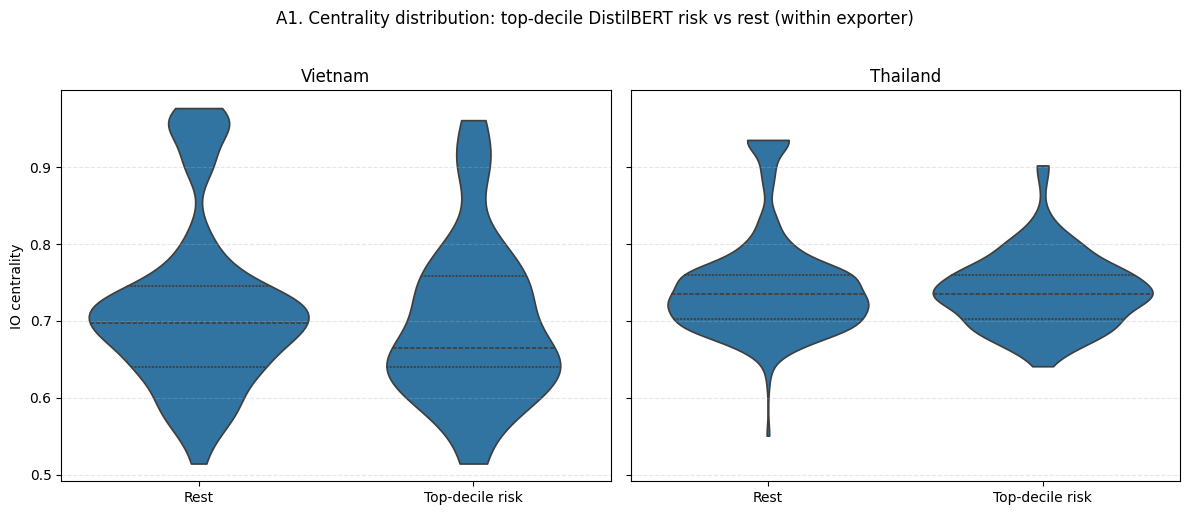

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_io_A_centrality_shift_key_exporters.png


In [11]:
# ------------------------------
# Figure A1: Centrality shift (key exporters)
# ------------------------------

plot_a = pred_io[pred_io['country'].isin(key_exporters)].copy()
plot_a['risk_group'] = np.where(plot_a['high_risk_top10_within_exporter'] == 1, 'Top-decile risk', 'Rest')

fig, axes = plt.subplots(1, len(key_exporters), figsize=(6 * len(key_exporters), 5), sharey=True)
if len(key_exporters) == 1:
    axes = [axes]

for ax, exporter in zip(axes, key_exporters):
    d = plot_a[plot_a['country'] == exporter].dropna(subset=['centrality'])
    sns.violinplot(data=d, x='risk_group', y='centrality', inner='quartile', cut=0, ax=ax)
    ax.set_title(exporter)
    ax.set_xlabel('')
    ax.set_ylabel('IO centrality')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('A1. Centrality distribution: top-decile DistilBERT risk vs rest (within exporter)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_A_CENTRALITY, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', FIG_A_CENTRALITY)

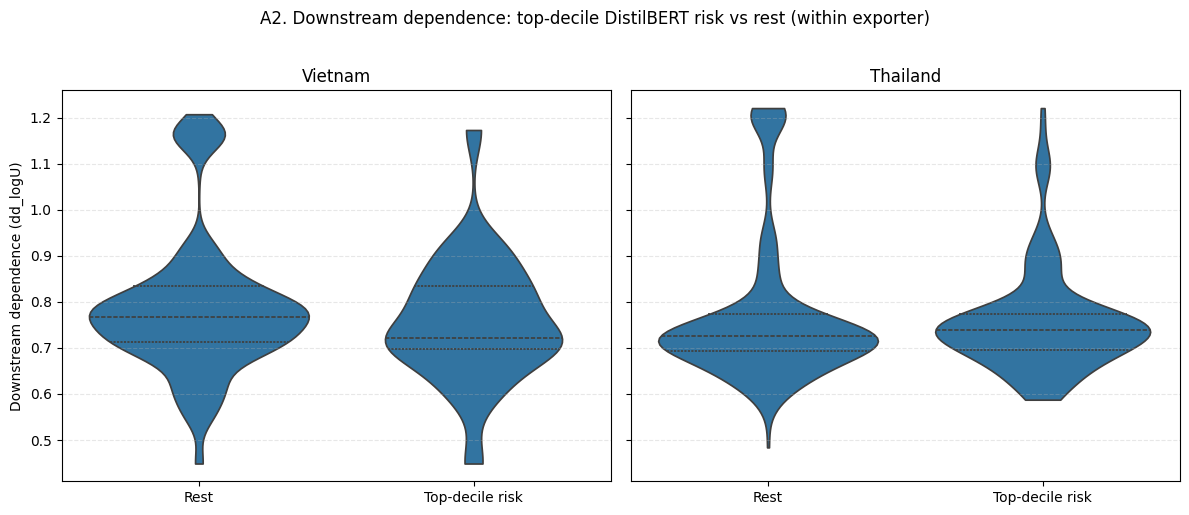

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_io_A_downstream_shift_key_exporters.png


In [12]:
# ------------------------------
# Figure A2: Downstream dependence shift (key exporters)
# ------------------------------

plot_a = pred_io[pred_io['country'].isin(key_exporters)].copy()
plot_a['risk_group'] = np.where(plot_a['high_risk_top10_within_exporter'] == 1, 'Top-decile risk', 'Rest')

fig, axes = plt.subplots(1, len(key_exporters), figsize=(6 * len(key_exporters), 5), sharey=True)
if len(key_exporters) == 1:
    axes = [axes]

for ax, exporter in zip(axes, key_exporters):
    d = plot_a[plot_a['country'] == exporter].dropna(subset=['dd_logU'])
    sns.violinplot(data=d, x='risk_group', y='dd_logU', inner='quartile', cut=0, ax=ax)
    ax.set_title(exporter)
    ax.set_xlabel('')
    ax.set_ylabel('Downstream dependence (dd_logU)')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('A2. Downstream dependence: top-decile DistilBERT risk vs rest (within exporter)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_A_DOWNSTREAM, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', FIG_A_DOWNSTREAM)

**7.6. Supplementary pattern checks**
- Binned scatter within exporter
- Pooled FE binned scatter

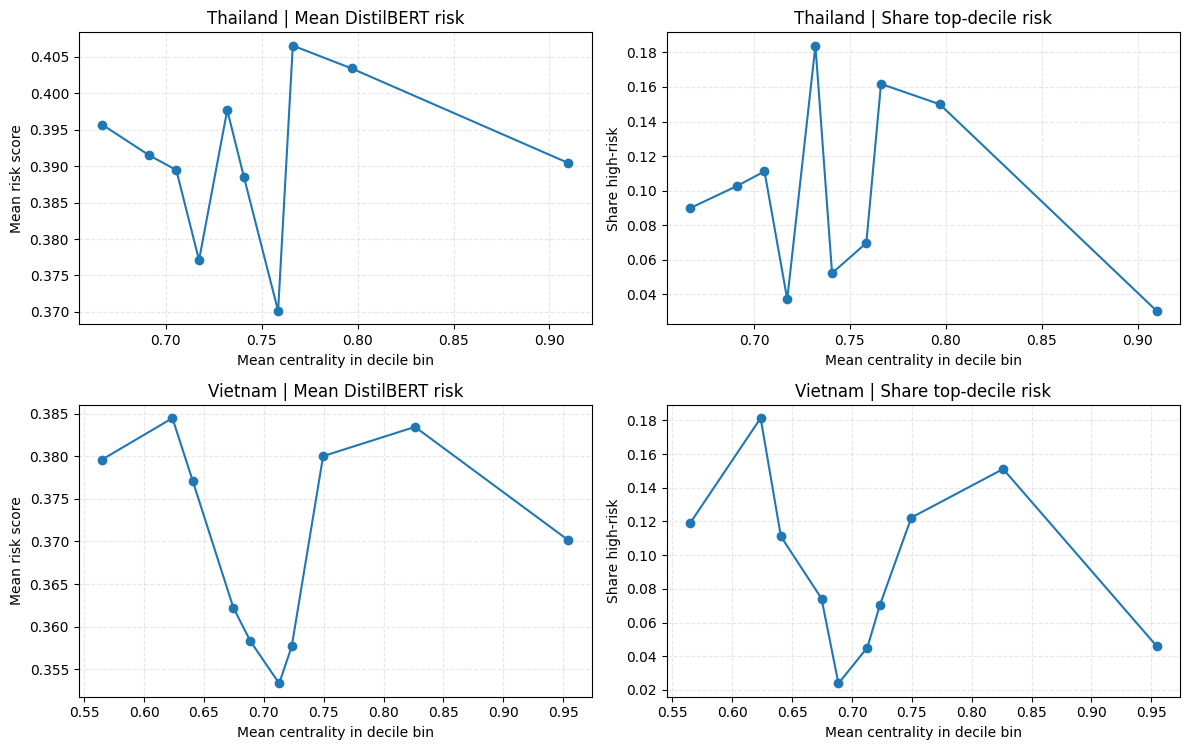

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_io_B_binned_within_exporter.png
Saved binned data: /content/drive/MyDrive/Project/data/cleaned_data/io_binned_scatter_data.csv


In [14]:
# ------------------------------
# B) Binned scatter within exporter (centrality deciles)
# X: centrality decile (within exporter)
# Y1: mean DistilBERT risk score
# Y2: share top-decile risk
# (restricted to key exporters)
# ------------------------------

binned_rows = []
for exporter, g in pred_io[pred_io['country'].isin(key_exporters)].groupby('country'):
    d = g[['centrality', 'p_hat', 'high_risk_top10_within_exporter']].dropna().copy()
    if len(d) < 30:
        continue

    # deciles within exporter
    d['bin'] = pd.qcut(d['centrality'], q=10, labels=False, duplicates='drop') + 1
    agg = d.groupby('bin', as_index=False).agg(
        mean_centrality=('centrality', 'mean'),
        mean_risk=('p_hat', 'mean'),
        share_top10=('high_risk_top10_within_exporter', 'mean'),
        n=('p_hat', 'size')
    )
    agg['country'] = exporter
    binned_rows.append(agg)

binned_within = pd.concat(binned_rows, ignore_index=True) if binned_rows else pd.DataFrame()

if not binned_within.empty:
    n_exp = binned_within['country'].nunique()
    fig, axes = plt.subplots(n_exp, 2, figsize=(12, 3.8 * n_exp), sharex=False)
    if n_exp == 1:
        axes = np.array([axes])

    for i, exporter in enumerate(sorted(binned_within['country'].unique())):
        d = binned_within[binned_within['country'] == exporter]

        axes[i, 0].plot(d['mean_centrality'], d['mean_risk'], marker='o')
        axes[i, 0].set_title(f'{exporter} | Mean DistilBERT risk')
        axes[i, 0].set_xlabel('Mean centrality in decile bin')
        axes[i, 0].set_ylabel('Mean risk score')
        axes[i, 0].grid(alpha=0.3, linestyle='--')

        axes[i, 1].plot(d['mean_centrality'], d['share_top10'], marker='o')
        axes[i, 1].set_title(f'{exporter} | Share top-decile risk')
        axes[i, 1].set_xlabel('Mean centrality in decile bin')
        axes[i, 1].set_ylabel('Share high-risk')
        axes[i, 1].grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(FIG_B_WITHIN, dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved:', FIG_B_WITHIN)
else:
    print('No sufficient data for within-exporter binned scatter.')

# Save binned data
if not binned_within.empty:
    binned_within.to_csv(OUT_BINS, index=False, encoding='utf-8')
    print('Saved binned data:', OUT_BINS)

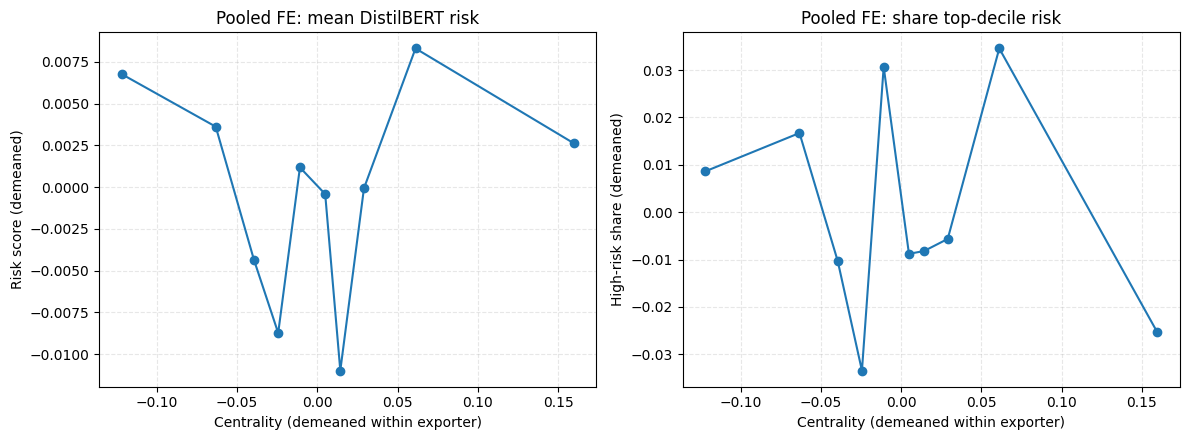

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_io_B_binned_pooled_fe.png


In [15]:
# ------------------------------
# B-appendix: pooled binned scatter with exporter fixed effects
# ------------------------------

d = pred_io[['country', 'centrality', 'p_hat', 'high_risk_top10_within_exporter']].dropna().copy()

# demean by exporter (fixed-effects style)
d['centrality_fe'] = d['centrality'] - d.groupby('country')['centrality'].transform('mean')
d['risk_fe'] = d['p_hat'] - d.groupby('country')['p_hat'].transform('mean')
d['highrisk_fe'] = d['high_risk_top10_within_exporter'] - d.groupby('country')['high_risk_top10_within_exporter'].transform('mean')

# bins on FE-adjusted centrality
d['bin'] = pd.qcut(d['centrality_fe'], q=10, labels=False, duplicates='drop') + 1
pooled_fe = d.groupby('bin', as_index=False).agg(
    mean_centrality_fe=('centrality_fe', 'mean'),
    mean_risk_fe=('risk_fe', 'mean'),
    mean_highrisk_fe=('highrisk_fe', 'mean'),
    n=('risk_fe', 'size')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(pooled_fe['mean_centrality_fe'], pooled_fe['mean_risk_fe'], marker='o')
axes[0].set_title('Pooled FE: mean DistilBERT risk')
axes[0].set_xlabel('Centrality (demeaned within exporter)')
axes[0].set_ylabel('Risk score (demeaned)')
axes[0].grid(alpha=0.3, linestyle='--')

axes[1].plot(pooled_fe['mean_centrality_fe'], pooled_fe['mean_highrisk_fe'], marker='o')
axes[1].set_title('Pooled FE: share top-decile risk')
axes[1].set_xlabel('Centrality (demeaned within exporter)')
axes[1].set_ylabel('High-risk share (demeaned)')
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(FIG_B_POOLED_FE, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', FIG_B_POOLED_FE)